Loading data...
Merging data...
Engineering features...
Splitting data into strict 15-day temporal holdout...
Training Baseline 1: Seasonal Naive
Seasonal Naive: RMSLE=0.5690, RMSE=353.80, MAPE=49.60%, R²=0.9192
Training Baseline 2: GD_Linear
GD_Linear: RMSLE=3.4470, RMSE=771479.02, MAPE=302.04%, R²=-384421.9653
Baseline execution completed!


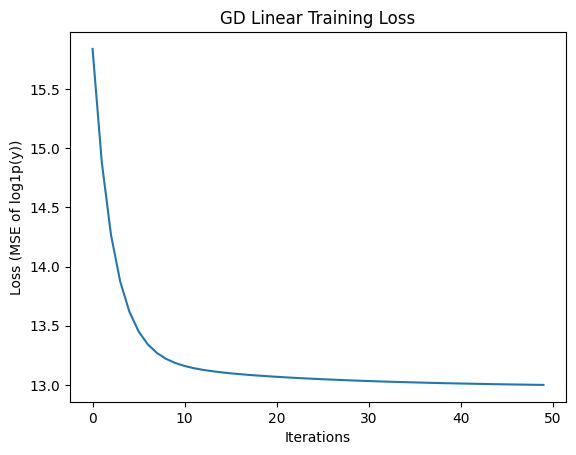

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from retail_iq.preprocessing import (
    load_raw_data,
    preprocess_dates,
    merge_datasets,
    detect_outliers_iqr,
    strict_temporal_holdout_split,
)
from retail_iq.features import FastFeatureEngineer
from retail_iq.models import SeasonalNaive, GD_Linear
from retail_iq.evaluation import evaluate_model
from retail_iq.config import MODEL_DIR, PLOT_DIR, set_global_seed

def run_baseline_pipeline():
    set_global_seed(42)
    print("Loading data...")
    train, test, stores, oil, holidays, tx = load_raw_data()
    train, test, oil, holidays, tx = preprocess_dates([train, test, oil, holidays, tx])
    
    print("Merging data...")
    df = merge_datasets(train, stores, oil, holidays, tx)
    
    print("Engineering features...")
    fe = FastFeatureEngineer(df, transactions=tx, oil_price=oil, holidays=holidays, store_meta=stores)
    fe.add_temporal_features()\
      .add_lag_and_rolling()\
      .add_onpromotion_features()\
      .add_macroeconomic_features()\
      .add_transaction_features()\
      .add_store_metadata()\
      .add_cannibalization_features()
      
    features_df = fe.transform()
    
    # Drop rows with NaNs from lags
    features_df = features_df.drop(columns=['sales_lag_365d'], errors='ignore')
    features_df = features_df.dropna(subset=['sales_lag_14d'])
    
    features_df = detect_outliers_iqr(features_df)
    
    # Force str conversion and encode
    for col in features_df.columns:
        if features_df[col].dtype == 'object' or pd.api.types.is_string_dtype(features_df[col]):
            features_df[col] = features_df[col].astype(str).astype('category').cat.codes
    
    print("Splitting data into strict 15-day temporal holdout...")
    train_df, test_df = strict_temporal_holdout_split(features_df, holdout_days=15)
    
    # Define features
    exclude_cols = ['id', 'date', 'sales', 'is_outlier']
    feature_cols = [c for c in train_df.columns if c not in exclude_cols]
    
    # Impute remaining nans
    train_df = train_df.fillna(0)
    test_df = test_df.fillna(0)
    
    X_train = train_df[feature_cols].to_numpy(dtype=np.float32, copy=False)
    y_train = train_df['sales'].to_numpy(dtype=np.float32, copy=False)

    X_test = test_df[feature_cols].to_numpy(dtype=np.float32, copy=False)
    y_test = test_df['sales'].to_numpy(dtype=np.float32, copy=False)
    
    print("Training Baseline 1: Seasonal Naive")
    naive_model = SeasonalNaive(period=7)
    y_pred_naive = features_df.groupby(['store_nbr', 'family'])['sales'].shift(7)
    test_naive_pred = y_pred_naive.loc[test_df.index].fillna(0).to_numpy(dtype=np.float32, copy=False)
    
    evaluate_model(y_test, test_naive_pred, "Seasonal Naive")
    joblib.dump(naive_model, MODEL_DIR / 'naive_baseline.pkl')
    
    print("Training Baseline 2: GD_Linear")
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Target transformation
    y_train_log = np.log1p(y_train)
    
    
    gd_model = GD_Linear(lr=0.01, iterations=50) 
    
    gd_model.fit(X_train_scaled, y_train_log)
    
    plt.figure()
    plt.plot(gd_model.loss_history)
    plt.title("GD Linear Training Loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss (MSE of log1p(y))")
    plt.savefig(PLOT_DIR / 'gd_loss.png')
    
    y_pred_log = gd_model.predict(X_test_scaled)
    y_pred_gd = np.expm1(y_pred_log)
    
    evaluate_model(y_test, y_pred_gd, "GD_Linear")
    joblib.dump(gd_model, MODEL_DIR / 'gd_linear_v1.pkl')
    joblib.dump(scaler, MODEL_DIR / 'gd_scaler.pkl')
    
    print("Baseline execution completed!")

if __name__ == '__main__':
    run_baseline_pipeline()